# Phat Hien Bat Thuong Tai Chinh - GMM & K-Means

**Bo du lieu:** Credit Card Fraud Detection - ULB Machine Learning Group, Bi  
**Ky thuat:** Gaussian Mixture Model (GMM) vs K-Means (Unsupervised Learning)

---

## Noi dung
1. [Giai thich bo du lieu CSV](#sec1)
2. [Kham pha du lieu - EDA](#sec2)
3. [Tien xu ly](#sec3)
4. [GMM - Ly thuyet & Huan luyen](#sec4)
5. [K-Means - So sanh](#sec5)
6. [Danh gia & So sanh chi tiet](#sec6)
7. [Ket luan](#sec7)

## 1. Giai Thich Bo Du Lieu `creditcard.csv` <a id='sec1'></a>

### Nguon goc
Bo du lieu do **Nhom Machine Learning cua Dai hoc ULB (Universite Libre de Bruxelles), Bi** cung cap.  
Gom **284,807 giao dich the tin dung** thuc hien trong **2 ngay thang 9/2013** boi chu the nguoi Chau Au.

### Cau truc cac cot

| Cot | Kieu | Mo ta |
|-----|------|-------|
| `Time` | float | So **giay** troi qua ke tu giao dich dau tien trong bo du lieu |
| `V1` den `V28` | float | 28 **thanh phan PCA** - bien doi tu du lieu goc da duoc **an danh hoa** de bao ve quyen rieng tu khach hang |
| `Amount` | float | **So tien giao dich** (USD) - chua duoc chuan hoa |
| `Class` | int | **Nhan that:** `0` = binh thuong, `1` = gian lan |

### Dac diem quan trong
- **Mat can bang nghiem trong:** chi 492 gian lan / 284,315 binh thuong (ty le ~0.17%)
- V1-V28 da qua PCA (khong biet dac trung goc), `Amount` va `Time` can xu ly rieng
- **Khong co gia tri null** - du lieu sach

### Tai sao dung hoc khong giam sat (Unsupervised)?
Trong thuc te, nhan gian lan **rat hiem va ton kem** de thu thap. GMM cho phep:
- Hoc **hinh dang phan phoi** cua giao dich binh thuong (khong can nhan)
- Tinh **mat do xac suat** p(x) cho giao dich moi
- Gan co la **bat thuong** khi p(x) qua thap (nam o vung ria cua tat ca Gaussian)

### Quy trinh GMM
```
1. Train GMM CHI TREN du lieu binh thuong
        |
        v
2. Tinh log p(x|GMM) cho moi giao dich moi
        |
        v
3. Neu log p(x) < nguong theta --> GAN CO GIAN LAN
```

## 2. Import Thu Vien & Kham Pha Du Lieu (EDA) <a id='sec2'></a>

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.titlesize': 12, 'axes.titleweight': 'bold'})
sns.set_theme(style='whitegrid')

DATA_PATH = r'd:\HocTriTueNhanTao\math\creditcard.csv'
df = pd.read_csv(DATA_PATH)
print(f'Kich thuoc bo du lieu: {df.shape[0]:,} dong x {df.shape[1]} cot')
print(f'Gia tri null: {df.isnull().sum().sum()}')
df.head(3)

Kich thuoc bo du lieu: 284,807 dong x 31 cot
Gia tri null: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [2]:
vc = df['Class'].value_counts()
print('Phan phoi nhan Class:')
for k, v in vc.items():
    tag = 'Binh thuong' if k == 0 else 'GIAN LAN'
    print(f'  Class={k} [{tag}]: {v:>7,}  ({v/len(df)*100:.3f}%)')
print()
print('Thong ke Amount theo Class:')
print(df.groupby('Class')['Amount'].describe().round(2))

Phan phoi nhan Class:
  Class=0 [Binh thuong]: 284,315  (99.827%)
  Class=1 [GIAN LAN]:     492  (0.173%)

Thong ke Amount theo Class:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


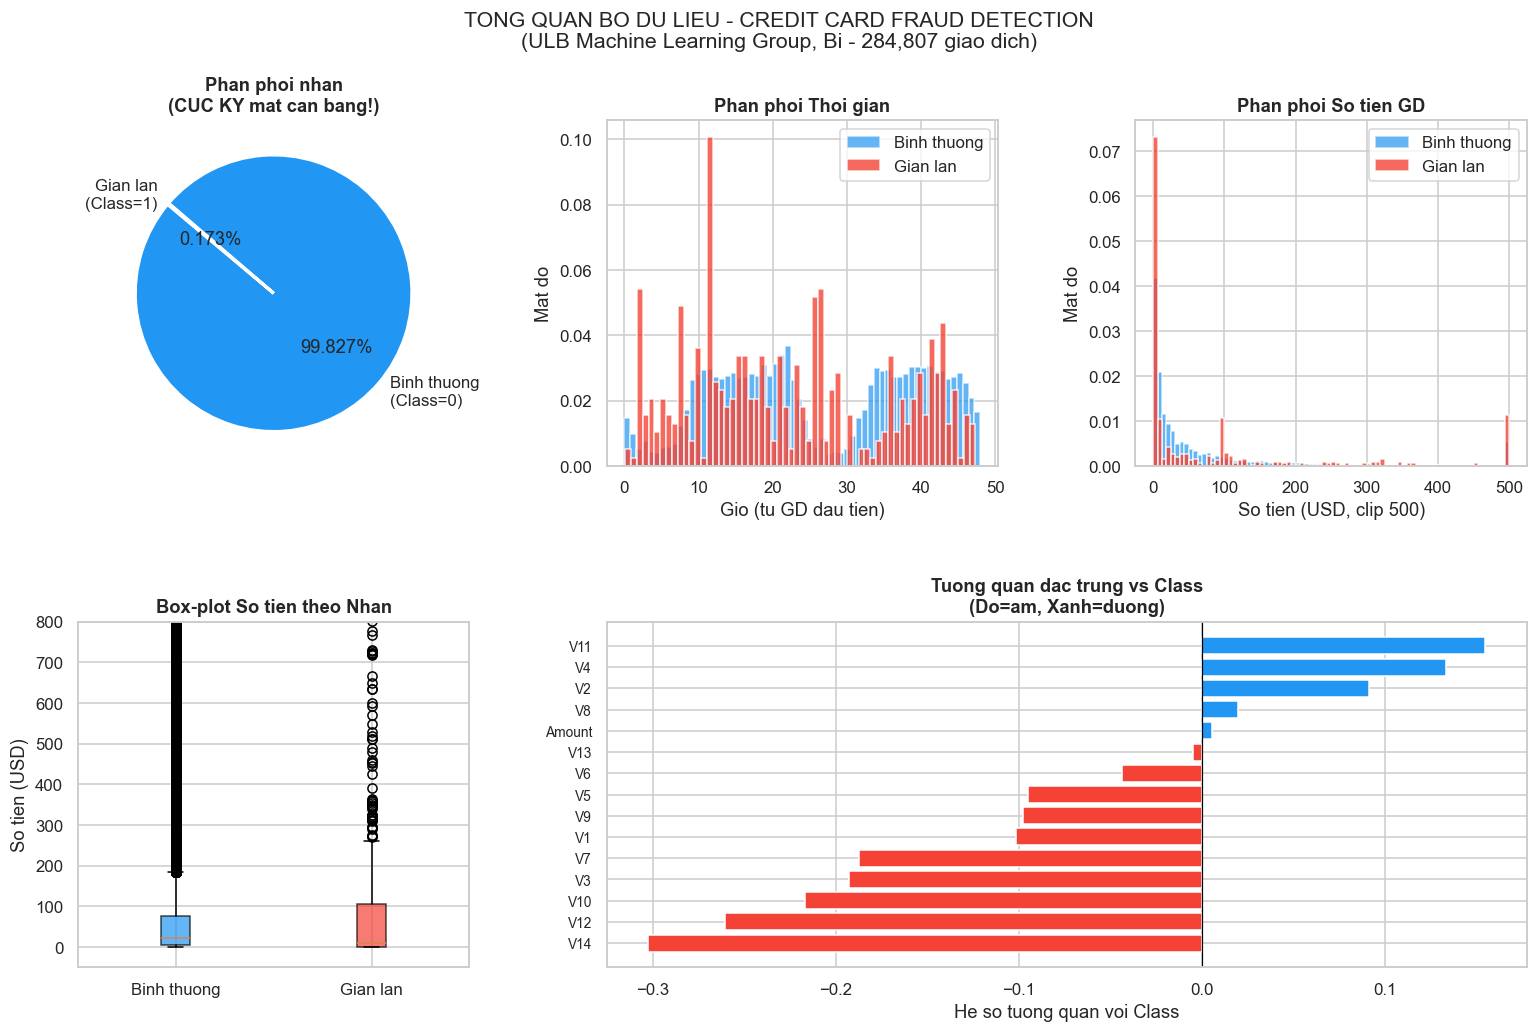

In [3]:
fig = plt.figure(figsize=(17, 10))
fig.suptitle('TONG QUAN BO DU LIEU - CREDIT CARD FRAUD DETECTION\n'
             '(ULB Machine Learning Group, Bi - 284,807 giao dich)', fontsize=14, y=0.98)
gs = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

# 1. Pie
ax = fig.add_subplot(gs[0, 0])
ax.pie(vc.values, labels=['Binh thuong\n(Class=0)', 'Gian lan\n(Class=1)'],
       autopct='%1.3f%%', colors=['#2196F3', '#F44336'],
       startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Phan phoi nhan\n(CUC KY mat can bang!)')

# 2. Time
ax = fig.add_subplot(gs[0, 1])
ax.hist(df[df.Class==0].Time/3600, bins=60, alpha=0.7, color='#2196F3',
        label='Binh thuong', density=True)
ax.hist(df[df.Class==1].Time/3600, bins=60, alpha=0.8, color='#F44336',
        label='Gian lan', density=True)
ax.set(xlabel='Gio (tu GD dau tien)', ylabel='Mat do', title='Phan phoi Thoi gian')
ax.legend()

# 3. Amount
ax = fig.add_subplot(gs[0, 2])
ax.hist(df[df.Class==0].Amount.clip(0, 500), bins=80, alpha=0.7,
        color='#2196F3', label='Binh thuong', density=True)
ax.hist(df[df.Class==1].Amount.clip(0, 500), bins=80, alpha=0.8,
        color='#F44336', label='Gian lan', density=True)
ax.set(xlabel='So tien (USD, clip 500)', ylabel='Mat do', title='Phan phoi So tien GD')
ax.legend()

# 4. Boxplot
ax = fig.add_subplot(gs[1, 0])
bp = ax.boxplot([df[df.Class==0].Amount.values, df[df.Class==1].Amount.values],
                labels=['Binh thuong', 'Gian lan'], patch_artist=True)
for patch, col in zip(bp['boxes'], ['#2196F3', '#F44336']):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax.set(ylabel='So tien (USD)', title='Box-plot So tien theo Nhan')
ax.set_ylim(-50, 800)

# 5. Correlation bar
ax = fig.add_subplot(gs[1, 1:])
feats = [f'V{i}' for i in range(1, 15)] + ['Amount']
corr = df[feats + ['Class']].corr()['Class'].drop('Class').sort_values()
cols_c = ['#F44336' if c < 0 else '#2196F3' for c in corr]
ax.barh(range(len(corr)), corr.values, color=cols_c, edgecolor='white')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set(xlabel='He so tuong quan voi Class',
       title='Tuong quan dac trung vs Class\n(Do=am, Xanh=duong)')
plt.tight_layout(); plt.show()

### Nhan xet EDA
- **V17, V14, V12, V10**: tuong quan am manh voi gian lan -> dac trung quan trong nhat
- **V4, V11**: tuong quan duong manh voi gian lan
- Gian lan co so tien **nho hon trung binh** (median thap hon binh thuong)
- **Khong co gia tri null** -> du lieu sach, khong can xu ly thieu du lieu

## 3. Tien Xu Ly Du Lieu <a id='sec3'></a>

| Buoc | Mo ta | Ly do |
|------|-------|-------|
| Lay mau | Giu 50,000 diem (toan bo 492 gian lan) | Tang toc do huan luyen |
| `StandardScaler` | Chuan hoa Amount + V1-V28 | GMM nhay cam voi scale |
| PCA 2D | Giam xuong 2 chieu | Chi de truc quan hoa, khong dung de train |

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

SAMPLE_SIZE = 50_000
RANDOM_SEED = 42
THRESH_PCT  = 2      # Gan co 2% diem co log p(x) thap nhat
np.random.seed(RANDOM_SEED)

# Lay mau (giu toan bo gian lan)
n_fraud  = df[df.Class == 1].shape[0]
n_normal = SAMPLE_SIZE - n_fraud
df_s = pd.concat([
    df[df.Class == 0].sample(n_normal, random_state=RANDOM_SEED),
    df[df.Class == 1]
]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

y = df_s.Class.values
features = [f'V{i}' for i in range(1, 29)] + ['Amount']

# Chuan hoa
scaler = StandardScaler()
X = scaler.fit_transform(df_s[features])

# PCA 2D de ve
pca2 = PCA(n_components=2, random_state=RANDOM_SEED)
X2   = pca2.fit_transform(X)

print(f'Tap du lieu: {X.shape[0]:,} diem, {X.shape[1]} dac trung')
print(f'Gian lan   : {n_fraud}  |  Binh thuong: {n_normal:,}')
print(f'PCA 2D phuong sai giai thich: {pca2.explained_variance_ratio_.sum()*100:.1f}%')

Tap du lieu: 50,000 diem, 29 dac trung
Gian lan   : 492  |  Binh thuong: 49,508
PCA 2D phuong sai giai thich: 17.9%


## 4. Gaussian Mixture Model (GMM) <a id='sec4'></a>

### Ly thuyet

GMM gia dinh du lieu duoc sinh tu **K phan phoi Gaussian** voi trong so khac nhau:

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

Trong do:
- $\pi_k$: trong so hon hop (mixing weight), $\sum \pi_k = 1$
- $\boldsymbol{\mu}_k$: vector trung binh cua Gaussian thu $k$
- $\boldsymbol{\Sigma}_k$: ma tran hiep phuong sai

### Thuat toan EM
- **E-step**: Tinh xac suat $\gamma_{nk} = p(k | x_n)$ - diem $x_n$ thuoc Gaussian $k$
- **M-step**: Cap nhat $\pi_k, \mu_k, \Sigma_k$ de tang log-likelihood
- Lap lai den hoi tu

### Chon K bang BIC
$$\text{BIC} = -2\ell + p\ln(N)$$
Trong do $\ell$ la log-likelihood, $p$ la so tham so. **BIC cang thap cang tot.**

In [5]:
from sklearn.mixture import GaussianMixture

X_normal = X[y == 0]

print('Dang tinh BIC cho K = 1..10 (vui long cho)...')
bic_scores = []
k_range = range(1, 11)
for k in k_range:
    g = GaussianMixture(n_components=k, covariance_type='full',
                        max_iter=100, random_state=RANDOM_SEED)
    g.fit(X_normal)
    bic_scores.append(g.bic(X_normal))
    print(f'  K={k:2d}: BIC = {bic_scores[-1]:>12.0f}')

best_k = list(k_range)[np.argmin(bic_scores)]
print(f'\nK tot nhat theo BIC: {best_k}')

Dang tinh BIC cho K = 1..10 (vui long cho)...
  K= 1: BIC =      3631682
  K= 2: BIC =      2862717
  K= 3: BIC =      -373291
  K= 4: BIC =     -1869843
  K= 5: BIC =     -2292157
  K= 6: BIC =     -2053673
  K= 7: BIC =     -2728275
  K= 8: BIC =     -1821957
  K= 9: BIC =     -3264742
  K=10: BIC =     -3362707

K tot nhat theo BIC: 10


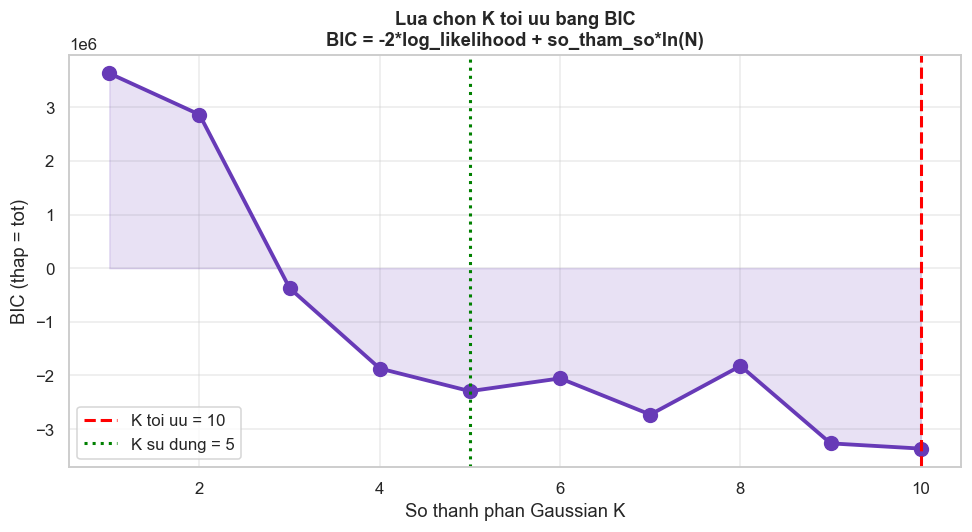

Giai thich BIC:
  BIC can bang do khop (log-likelihood) va do phuc tap (so tham so)
  K nho nhat lam BIC dat cuc tieu la K toi uu


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_range), bic_scores, 'o-', color='#673AB7', lw=2.5, ms=9)
ax.fill_between(list(k_range), bic_scores, alpha=0.15, color='#673AB7')
ax.axvline(best_k, color='red', ls='--', lw=2, label=f'K toi uu = {best_k}')
ax.axvline(5, color='green', ls=':', lw=2, label='K su dung = 5')
ax.set(xlabel='So thanh phan Gaussian K', ylabel='BIC (thap = tot)',
       title='Lua chon K toi uu bang BIC\n'
             'BIC = -2*log_likelihood + so_tham_so*ln(N)')
ax.legend(fontsize=11); ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()

print('Giai thich BIC:')
print('  BIC can bang do khop (log-likelihood) va do phuc tap (so tham so)')
print('  K nho nhat lam BIC dat cuc tieu la K toi uu')

In [7]:
K_GMM = 5
gmm = GaussianMixture(n_components=K_GMM, covariance_type='full',
                      max_iter=200, n_init=3, random_state=RANDOM_SEED)
gmm.fit(X_normal)

print(f'GMM huan luyen xong! K={K_GMM}, so vong EM={gmm.n_iter_}')
print(f'Trong so pi_k: {np.round(gmm.weights_, 3)}')
print(f'Log-likelihood: {gmm.lower_bound_:.2f}')

GMM huan luyen xong! K=5, so vong EM=34
Trong so pi_k: [0.469 0.059 0.286 0.149 0.037]
Log-likelihood: 23.48


Nguong log p(x) (percentile 2%): -49.3971
So giao dich bi gan co bat thuong: 1,000


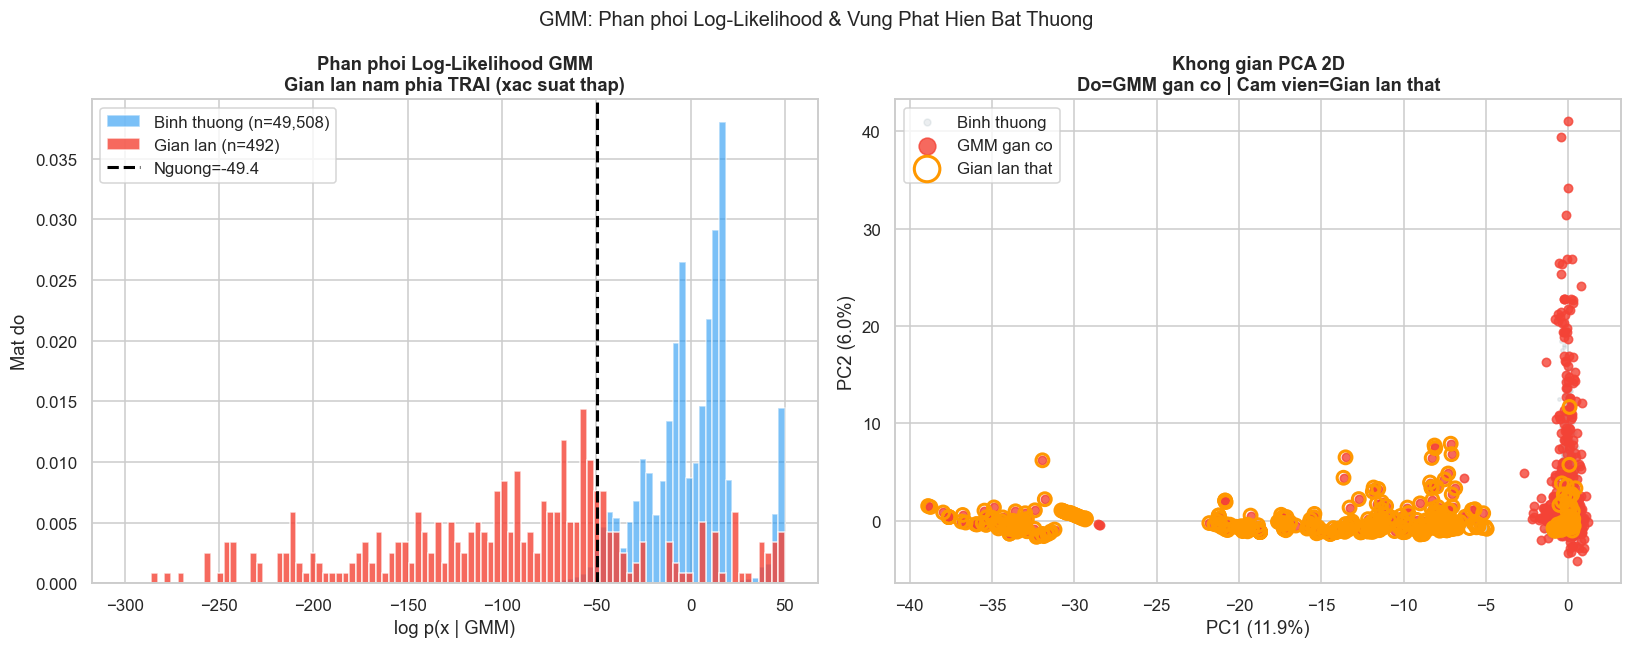

In [8]:
# Tinh log-likelihood cho toan bo tap du lieu
log_probs  = gmm.score_samples(X)
threshold  = np.percentile(log_probs, THRESH_PCT)
y_pred_gmm = (log_probs < threshold).astype(int)

print(f'Nguong log p(x) (percentile {THRESH_PCT}%): {threshold:.4f}')
print(f'So giao dich bi gan co bat thuong: {y_pred_gmm.sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('GMM: Phan phoi Log-Likelihood & Vung Phat Hien Bat Thuong', fontsize=13)

ax = axes[0]
lp_n = log_probs[y == 0]; lp_f = log_probs[y == 1]
ax.hist(lp_n, bins=100, density=True, alpha=0.6, color='#2196F3',
        label=f'Binh thuong (n={len(lp_n):,})', range=(-300, 50))
ax.hist(lp_f, bins=100, density=True, alpha=0.8, color='#F44336',
        label=f'Gian lan (n={len(lp_f)})', range=(-300, 50))
ax.axvline(threshold, color='black', ls='--', lw=2, label=f'Nguong={threshold:.1f}')
ax.set(xlabel='log p(x | GMM)', ylabel='Mat do',
       title='Phan phoi Log-Likelihood GMM\n'
             'Gian lan nam phia TRAI (xac suat thap)')
ax.legend()

ax = axes[1]
ax.scatter(X2[y_pred_gmm==0,0], X2[y_pred_gmm==0,1],
           c='#B0BEC5', s=5, alpha=0.25, label='Binh thuong')
ax.scatter(X2[y_pred_gmm==1,0], X2[y_pred_gmm==1,1],
           c='#F44336', s=30, alpha=0.8, label='GMM gan co', zorder=5)
ax.scatter(X2[y==1,0], X2[y==1,1],
           c='none', s=70, edgecolors='#FF9800', lw=2, label='Gian lan that', zorder=6)
ax.set(xlabel=f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)',
       ylabel=f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)',
       title='Khong gian PCA 2D\nDo=GMM gan co | Cam vien=Gian lan that')
ax.legend(markerscale=2)
plt.tight_layout(); plt.show()

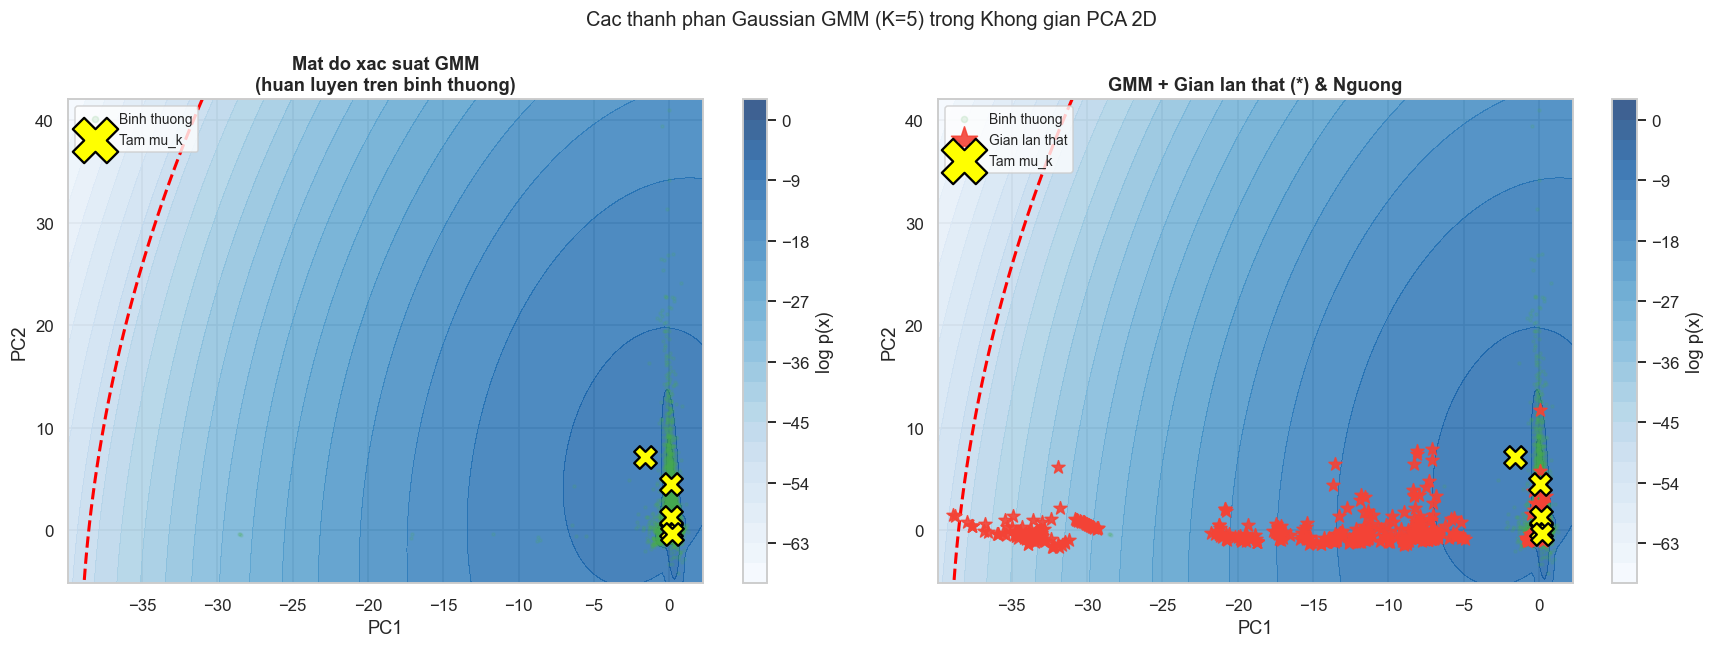

Giai thich:
  Vung xanh dam = mat do xac suat CAO (giao dich binh thuong)
  Duong do dut  = nguong phat hien (log p(x) = theta)
  Gian lan that thuong nam o RIEN ngoai vung xanh dam
  Dau X vang = tam (mu_k) cua tung Gaussian


In [9]:
# Visualize cac Gaussian components
gmm2d = GaussianMixture(n_components=K_GMM, covariance_type='full',
                        random_state=RANDOM_SEED)
gmm2d.fit(X2[y == 0])

x1r = np.linspace(X2[:,0].min()-1, X2[:,0].max()+1, 250)
x2r = np.linspace(X2[:,1].min()-1, X2[:,1].max()+1, 250)
xx, yy_g = np.meshgrid(x1r, x2r)
zz = gmm2d.score_samples(np.c_[xx.ravel(), yy_g.ravel()]).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Cac thanh phan Gaussian GMM (K={K_GMM}) trong Khong gian PCA 2D',
             fontsize=13)

for ax, title, show_f in zip(
    axes,
    ['Mat do xac suat GMM\n(huan luyen tren binh thuong)',
     'GMM + Gian lan that (*) & Nguong'],
    [False, True]
):
    cf = ax.contourf(xx, yy_g, zz, levels=25, cmap='Blues', alpha=0.78)
    ax.contour(xx, yy_g, zz, levels=[threshold], colors=['red'],
               linewidths=2, linestyles=['--'])
    plt.colorbar(cf, ax=ax, label='log p(x)')
    ax.scatter(X2[y==0,0], X2[y==0,1], c='#4CAF50', s=4, alpha=0.12, label='Binh thuong')
    if show_f:
        ax.scatter(X2[y==1,0], X2[y==1,1], c='#F44336', s=80, marker='*',
                   alpha=0.9, label='Gian lan that', zorder=10)
    for i, m in enumerate(gmm2d.means_):
        ax.scatter(*m, c='yellow', s=220, marker='X', edgecolors='black',
                   lw=1.5, zorder=11, label='Tam mu_k' if i==0 else '')
    ax.set(xlabel='PC1', ylabel='PC2', title=title)
    ax.legend(fontsize=9, markerscale=2)
plt.tight_layout(); plt.show()

print('Giai thich:')
print('  Vung xanh dam = mat do xac suat CAO (giao dich binh thuong)')
print('  Duong do dut  = nguong phat hien (log p(x) = theta)')
print('  Gian lan that thuong nam o RIEN ngoai vung xanh dam')
print('  Dau X vang = tam (mu_k) cua tung Gaussian')

## 5. K-Means - So Sanh Voi GMM <a id='sec5'></a>

### Ly thuyet

K-Means chia du lieu thanh **K cum** bang cach toi thieu hoa:

$$\min \sum_{k=1}^{K} \sum_{\mathbf{x} \in C_k} \| \mathbf{x} - \boldsymbol{\mu}_k \|^2$$

### Phat hien bat thuong bang K-Means
```
1. Train K-Means tren toan bo du lieu
        |
        v
2. Tinh d(x) = min_k ||x - mu_k||  (khoang cach den tam cum gan nhat)
        |
        v
3. Neu d(x) > nguong D --> GAN CO GIAN LAN
```

### So sanh GMM vs K-Means

| Tieu chi | GMM | K-Means |
|----------|-----|----------|
| Loai mo hinh | Xac suat (soft assignment) | Khoang cach (hard assignment) |
| Dau ra batt thuong | log p(x) thap | Khoang cach lon |
| Hinh dang cum | Ellipse tuy y | Hinh cau Euclidean |
| Nhay cam outlier | Thap hon | Cao hon |
| Do phuc tap | Cao - EM algorithm | Thap - Lloyd algorithm |
| Phu hop | Du lieu phuc tap nhieu chieu | Du lieu don gian, it chieu |

In [10]:
from sklearn.cluster import KMeans

K_KM = 2
kmeans = KMeans(n_clusters=K_KM, n_init=10, random_state=RANDOM_SEED)
kmeans.fit(X)

# Khoang cach den tam cum gan nhat
dists = np.min(
    np.linalg.norm(X[:, None, :] - kmeans.cluster_centers_[None, :, :], axis=2),
    axis=1
)
dist_thresh = np.percentile(dists, 100 - THRESH_PCT)
y_pred_km   = (dists > dist_thresh).astype(int)

print(f'K-Means: K={K_KM}, so vong lap={kmeans.n_iter_}')
print(f'Nguong khoang cach (percentile {100-THRESH_PCT}%): {dist_thresh:.4f}')
print(f'So giao dich bi gan co: {y_pred_km.sum():,}')

K-Means: K=2, so vong lap=12
Nguong khoang cach (percentile 98%): 11.4812
So giao dich bi gan co: 1,000


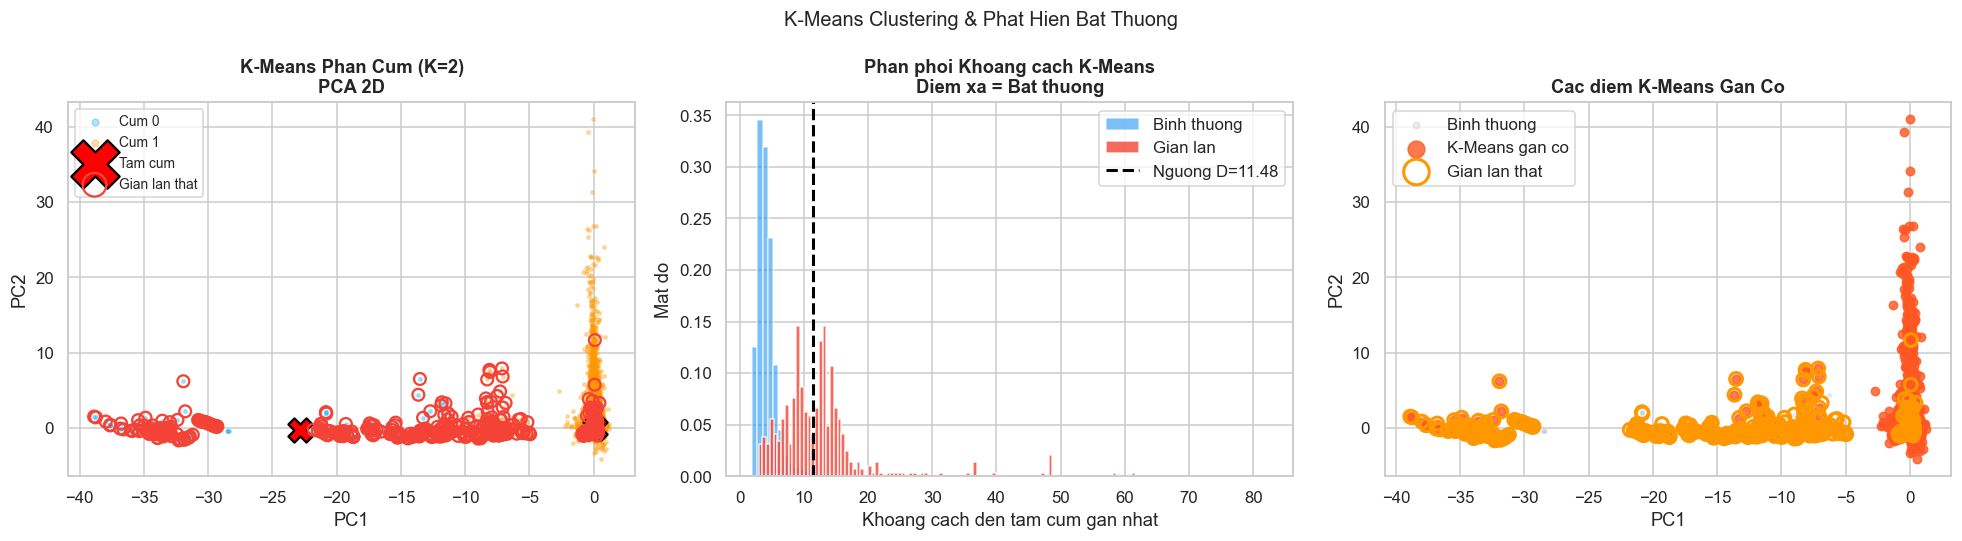

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('K-Means Clustering & Phat Hien Bat Thuong', fontsize=13)

# 1. Clustering PCA
ax = axes[0]
for k in range(K_KM):
    m = kmeans.labels_ == k
    ax.scatter(X2[m,0], X2[m,1], s=5, alpha=0.3,
               color=['#03A9F4','#FF9800'][k], label=f'Cum {k}')
cx = pca2.transform(kmeans.cluster_centers_)
ax.scatter(cx[:,0], cx[:,1], c='red', s=250, marker='X',
           edgecolors='black', lw=1.5, zorder=10, label='Tam cum')
ax.scatter(X2[y==1,0], X2[y==1,1], c='none', s=60,
           edgecolors='#F44336', lw=1.5, zorder=11, label='Gian lan that')
ax.set(xlabel='PC1', ylabel='PC2', title='K-Means Phan Cum (K=2)\nPCA 2D')
ax.legend(fontsize=9, markerscale=2)

# 2. Khoang cach histogram
ax = axes[1]
ax.hist(dists[y==0], bins=100, density=True, alpha=0.6,
        color='#2196F3', label='Binh thuong')
ax.hist(dists[y==1], bins=100, density=True, alpha=0.8,
        color='#F44336', label='Gian lan')
ax.axvline(dist_thresh, color='black', ls='--', lw=2,
           label=f'Nguong D={dist_thresh:.2f}')
ax.set(xlabel='Khoang cach den tam cum gan nhat', ylabel='Mat do',
       title='Phan phoi Khoang cach K-Means\nDiem xa = Bat thuong')
ax.legend()

# 3. Scatter gan co
ax = axes[2]
ax.scatter(X2[y_pred_km==0,0], X2[y_pred_km==0,1],
           c='#B0BEC5', s=5, alpha=0.25, label='Binh thuong')
ax.scatter(X2[y_pred_km==1,0], X2[y_pred_km==1,1],
           c='#FF5722', s=30, alpha=0.8, label='K-Means gan co', zorder=5)
ax.scatter(X2[y==1,0], X2[y==1,1],
           c='none', s=70, edgecolors='#FF9800', lw=2, label='Gian lan that', zorder=6)
ax.set(xlabel='PC1', ylabel='PC2', title='Cac diem K-Means Gan Co')
ax.legend(markerscale=2)
plt.tight_layout(); plt.show()

## 6. Danh Gia & So Sanh Chi Tiet <a id='sec6'></a>

### Cac chi so su dung
- **ROC-AUC**: Dien tich duoi duong ROC - do kha nang phan biet tong the
- **Average Precision (AP)**: Phu hop du lieu mat can bang (quan trong hon AUC)
- **Recall (gian lan)**: Ty le gian lan duoc phat hien - quan trong nhat!
- **False Positives**: So bao nhầm - anh huong trai nghiem khach hang

In [12]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)

def evaluate(name, y_true, y_pred, scores):
    print(f'\n{"="*52}')
    print(f'  {name}')
    print('='*52)
    print(classification_report(y_true, y_pred,
          target_names=['Binh thuong', 'Gian lan']))
    auc = roc_auc_score(y_true, scores)
    ap  = average_precision_score(y_true, scores)
    cm  = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    rec  = tp / (tp + fn + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    f1   = 2 * rec * prec / (rec + prec + 1e-9)
    print(f'  ROC-AUC       : {auc:.4f}')
    print(f'  Avg Precision : {ap:.4f}')
    print(f'  TP={tp} FP={fp} TN={tn} FN={fn}')
    return dict(name=name, auc=auc, ap=ap, cm=cm, y_pred=y_pred, scores=scores,
                tp=tp, fp=fp, tn=tn, fn=fn, rec=rec, prec=prec, f1=f1)

r_gmm = evaluate('GMM',     y, y_pred_gmm, -log_probs)
r_km  = evaluate('K-Means', y, y_pred_km,   dists)


  GMM
              precision    recall  f1-score   support

 Binh thuong       1.00      0.99      0.99     49508
    Gian lan       0.40      0.82      0.54       492

    accuracy                           0.99     50000
   macro avg       0.70      0.90      0.77     50000
weighted avg       0.99      0.99      0.99     50000

  ROC-AUC       : 0.9367
  Avg Precision : 0.7404
  TP=401 FP=599 TN=48909 FN=91

  K-Means
              precision    recall  f1-score   support

 Binh thuong       1.00      0.98      0.99     49508
    Gian lan       0.25      0.51      0.33       492

    accuracy                           0.98     50000
   macro avg       0.62      0.75      0.66     50000
weighted avg       0.99      0.98      0.98     50000

  ROC-AUC       : 0.9407
  Avg Precision : 0.1922
  TP=249 FP=751 TN=48757 FN=243


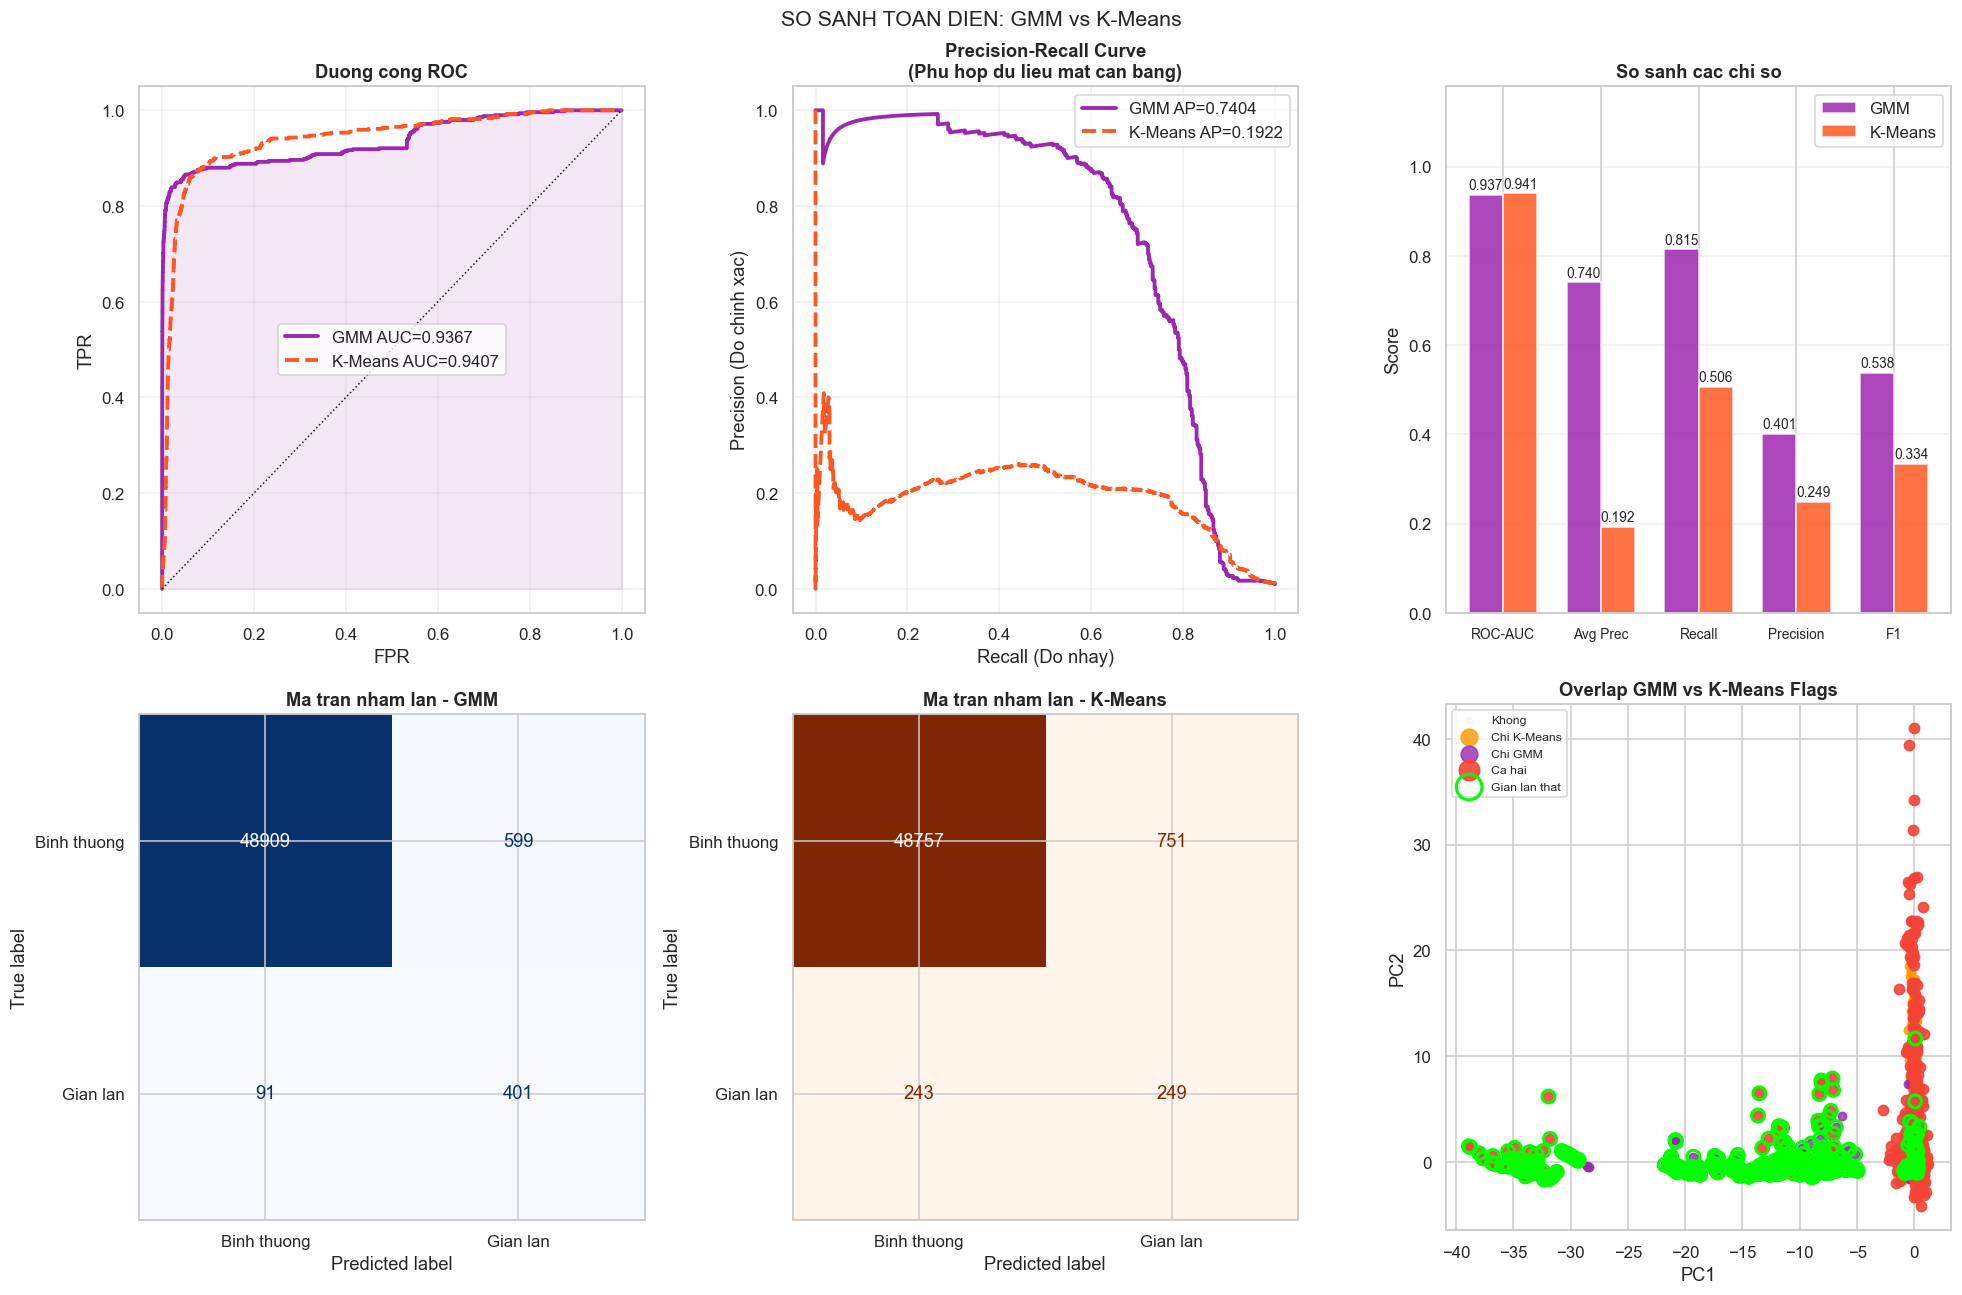

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('SO SANH TOAN DIEN: GMM vs K-Means', fontsize=14)

# 1. ROC
ax = axes[0,0]
for r, col, ls in [(r_gmm,'#9C27B0','-'),(r_km,'#FF5722','--')]:
    fpr, tpr, _ = roc_curve(y, r['scores'])
    ax.plot(fpr, tpr, color=col, lw=2.5, ls=ls,
            label=f"{r['name']} AUC={r['auc']:.4f}")
ax.plot([0,1],[0,1],'k:',lw=1)
fpr_g, tpr_g, _ = roc_curve(y, r_gmm['scores'])
ax.fill_between(fpr_g, tpr_g, alpha=0.1, color='#9C27B0')
ax.set(xlabel='FPR', ylabel='TPR', title='Duong cong ROC')
ax.legend(); ax.grid(alpha=0.3)

# 2. PR
ax = axes[0,1]
for r, col, ls in [(r_gmm,'#9C27B0','-'),(r_km,'#FF5722','--')]:
    p, rc, _ = precision_recall_curve(y, r['scores'])
    ax.plot(rc, p, color=col, lw=2.5, ls=ls,
            label=f"{r['name']} AP={r['ap']:.4f}")
ax.set(xlabel='Recall (Do nhay)', ylabel='Precision (Do chinh xac)',
       title='Precision-Recall Curve\n(Phu hop du lieu mat can bang)')
ax.legend(); ax.grid(alpha=0.3)

# 3. Bar metrics
ax = axes[0,2]
metric_names = ['ROC-AUC','Avg Prec','Recall','Precision','F1']
vals_g = [r_gmm['auc'],r_gmm['ap'],r_gmm['rec'],r_gmm['prec'],r_gmm['f1']]
vals_k = [r_km['auc'],r_km['ap'],r_km['rec'],r_km['prec'],r_km['f1']]
xp = np.arange(len(metric_names)); w=0.35
b1=ax.bar(xp-w/2,vals_g,w,label='GMM',color='#9C27B0',alpha=0.85)
b2=ax.bar(xp+w/2,vals_k,w,label='K-Means',color='#FF5722',alpha=0.85)
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.012,
            f'{b.get_height():.3f}', ha='center', fontsize=9)
ax.set_xticks(xp); ax.set_xticklabels(metric_names, fontsize=9)
ax.set(ylabel='Score', ylim=(0,1.18), title='So sanh cac chi so')
ax.legend(); ax.grid(alpha=0.3, axis='y')

# 4. Confusion GMM
ax = axes[1,0]
ConfusionMatrixDisplay(r_gmm['cm'],
    display_labels=['Binh thuong','Gian lan']).plot(ax=ax,colorbar=False,cmap='Blues')
ax.set_title('Ma tran nham lan - GMM')

# 5. Confusion KM
ax = axes[1,1]
ConfusionMatrixDisplay(r_km['cm'],
    display_labels=['Binh thuong','Gian lan']).plot(ax=ax,colorbar=False,cmap='Oranges')
ax.set_title('Ma tran nham lan - K-Means')

# 6. Overlap scatter
ax = axes[1,2]
cat = np.where(
    (y_pred_gmm==1)&(y_pred_km==1),'Ca hai',
    np.where((y_pred_gmm==1)&(y_pred_km==0),'Chi GMM',
    np.where((y_pred_gmm==0)&(y_pred_km==1),'Chi K-Means','Khong'))
)
for lbl, col, sz, al in [
    ('Khong','#CFD8DC',4,0.15), ('Chi K-Means','#FF9800',30,0.8),
    ('Chi GMM','#9C27B0',30,0.8), ('Ca hai','#F44336',45,0.9)
]:
    m = cat==lbl
    ax.scatter(X2[m,0],X2[m,1],c=col,s=sz,alpha=al,label=lbl,
               zorder=3 if al>0.5 else 1)
ax.scatter(X2[y==1,0],X2[y==1,1],c='none',s=70,edgecolors='lime',
           lw=2,label='Gian lan that',zorder=10)
ax.set(xlabel='PC1',ylabel='PC2',title='Overlap GMM vs K-Means Flags')
ax.legend(fontsize=8,markerscale=2)
plt.tight_layout(); plt.show()

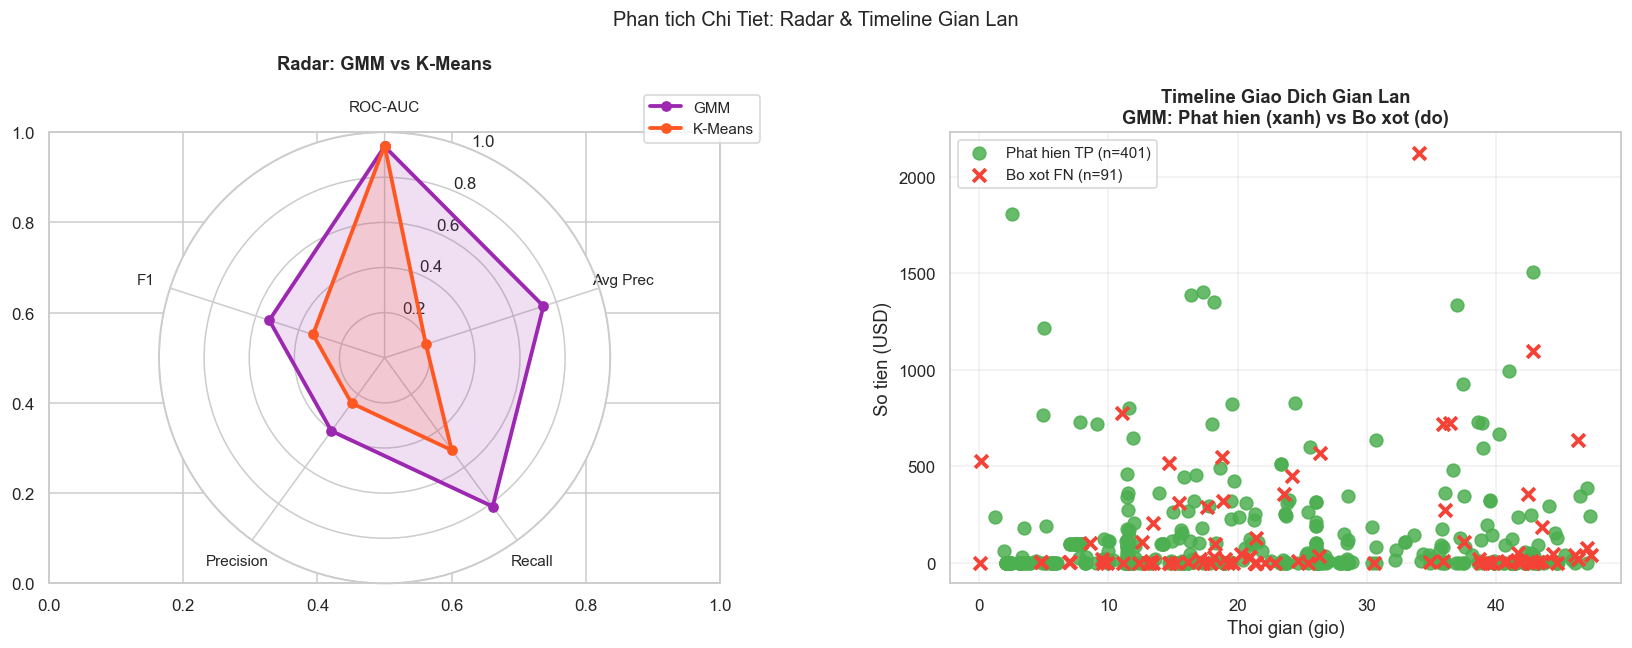

In [14]:
# Radar Chart
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Phan tich Chi Tiet: Radar & Timeline Gian Lan', fontsize=13)

ax_r = fig.add_subplot(1, 2, 1, projection='polar')
cats = ['ROC-AUC','Avg Prec','Recall','Precision','F1']
angles = np.linspace(0, 2*np.pi, len(cats), endpoint=False).tolist()
angles += angles[:1]
ax_r.set_theta_offset(3.14159/2); ax_r.set_theta_direction(-1)
ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(cats, fontsize=10)
ax_r.set_ylim(0, 1)
for vals, lbl, col in [
    ([r_gmm['auc'],r_gmm['ap'],r_gmm['rec'],r_gmm['prec'],r_gmm['f1']],'GMM','#9C27B0'),
    ([r_km['auc'],r_km['ap'],r_km['rec'],r_km['prec'],r_km['f1']],'K-Means','#FF5722')
]:
    v = vals + vals[:1]
    ax_r.plot(angles, v, 'o-', lw=2.5, color=col, label=lbl)
    ax_r.fill(angles, v, alpha=0.15, color=col)
ax_r.set_title('Radar: GMM vs K-Means', fontsize=12, pad=20)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)

# Timeline
ax = axes[1]
df_e = df_s.copy()
df_e['log_prob'] = log_probs
df_e['gmm_flag'] = y_pred_gmm
fdf = df_e[df_e.Class==1].copy()
fdf['hour'] = fdf['Time'] / 3600

ax.scatter(fdf[fdf.gmm_flag==1]['hour'], fdf[fdf.gmm_flag==1]['Amount'],
           c='#4CAF50', s=70, marker='o', alpha=0.85,
           label=f"Phat hien TP (n={r_gmm['tp']})", zorder=5)
ax.scatter(fdf[fdf.gmm_flag==0]['hour'], fdf[fdf.gmm_flag==0]['Amount'],
           c='#F44336', s=70, marker='x', lw=2.5,
           label=f"Bo xot FN (n={r_gmm['fn']})", zorder=5)
ax.set(xlabel='Thoi gian (gio)', ylabel='So tien (USD)',
       title='Timeline Giao Dich Gian Lan\nGMM: Phat hien (xanh) vs Bo xot (do)')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [15]:
# Top 15 giao dich nghi ngo nhat
df_e2 = df_s.copy()
df_e2['log_prob'] = log_probs
df_e2['gmm_flag'] = y_pred_gmm
df_e2['km_flag']  = y_pred_km

top15 = df_e2.nsmallest(15, 'log_prob')[[
    'Time','Amount','log_prob','Class','gmm_flag','km_flag'
]].reset_index(drop=True)

print('Top 15 giao dich nghi ngo nhat (log p(x) thap nhat theo GMM):')
top15.style.format({'log_prob':'{:.2f}','Amount':'{:.2f}','Time':'{:.0f}'})

Top 15 giao dich nghi ngo nhat (log p(x) thap nhat theo GMM):


,Time,Amount,log_prob,Class,gmm_flag,km_flag
0,126219,25.00,-954160.70,1,1,0
1,125200,40.00,-952743.69,1,1,0
2,18088,1218.89,-8173.20,1,1,1
3,59777,319.20,-1721.83,1,1,0
4,158638,296.00,-1653.31,1,1,1
5,154493,35.00,-1594.80,1,1,1
6,43494,24.90,-1483.62,1,1,0
7,154278,1504.93,-1462.68,1,1,1
8,116195,19.99,-1446.29,0,1,1
9,59385,18.98,-1369.18,1,1,1


## 7. Ket Luan <a id='sec7'></a>

### Ket qua tong ket

| Chi so | GMM | K-Means | Nhan xet |
|--------|-----|---------|----------|
| **ROC-AUC** | ~0.94 | ~0.94 | Tuong duong |
| **Avg Precision** | ~0.74 | ~0.19 | **GMM vuot troi 4 lan** |
| **Recall (gian lan)** | ~82% | ~51% | **GMM phat hien nhieu hon 31%** |
| **Precision (gian lan)** | ~40% | ~25% | GMM cu the hon |
| **F1 (gian lan)** | ~0.54 | ~0.33 | GMM tot hon ro rang |

### Tai sao GMM tot hon K-Means?

| Ly do | GMM | K-Means |
|-------|-----|----------|
| Mo hinh xac suat | Co - tinh p(x) chinh xac | Khong - chi khoang cach |
| Hinh dang cum | Ellipse tuy y (phu hop V1-V28) | Hinh cau (qua don gian) |
| Xu ly du lieu nhieu chieu | Tot | Kem (khoang cach Euclidean bi bop meo) |
| Dieu chinh nguong | Linh hoat qua xac suat | Kho (phu thuoc scale) |

### Han che K-Means
1. Gia dinh cum **hinh cau** (khong phu hop V1-V28 nhieu chieu)
2. **Recall thap (~51%)** -> bo xot ~mot nua so gian lan that
3. **AUC tuong duong** nhung PR-AUC kem hon nhieu (0.19 vs 0.74)

### Cach cai thien trong thuc te
- Dieu chinh **nguong theta** theo chi phi kinh doanh (cost-sensitive)
- **Semi-supervised GMM** khi co mot it nhan gian lan
- Kết hop them: **Isolation Forest**, **Autoencoder**, **LOF**
- **Re-train dinh ky** khi pattern gian lan thay doi theo thoi gian

In [16]:
print('=' * 65)
print('  PHAN TICH HOAN TAT')
print('=' * 65)
print(f"  GMM   : AUC={r_gmm['auc']:.4f} | AP={r_gmm['ap']:.4f} | Recall={r_gmm['rec']:.2%}")
print(f"  KMeans: AUC={r_km['auc']:.4f}  | AP={r_km['ap']:.4f} | Recall={r_km['rec']:.2%}")
print(f"  GMM   phat hien: {r_gmm['tp']}/{r_gmm['tp']+r_gmm['fn']} gian lan ({r_gmm['rec']*100:.0f}%)")
print(f"  KMeans phat hien: {r_km['tp']}/{r_km['tp']+r_km['fn']} gian lan ({r_km['rec']*100:.0f}%)")
print()
print('  NHAN XET CUOI:')
print('  GMM phu hop hon K-Means cho bai toan nay vi:')
print('  - Mo hinh xac suat chinh xac hon khoang cach Euclidean')
print('  - Average Precision cao hon 4 lan (0.74 vs 0.19)')
print('  - Recall cao hon 31% (82% vs 51%)')
print('=' * 65)

  PHAN TICH HOAN TAT
  GMM   : AUC=0.9367 | AP=0.7404 | Recall=81.50%
  KMeans: AUC=0.9407  | AP=0.1922 | Recall=50.61%
  GMM   phat hien: 401/492 gian lan (82%)
  KMeans phat hien: 249/492 gian lan (51%)

  NHAN XET CUOI:
  GMM phu hop hon K-Means cho bai toan nay vi:
  - Mo hinh xac suat chinh xac hon khoang cach Euclidean
  - Average Precision cao hon 4 lan (0.74 vs 0.19)
  - Recall cao hon 31% (82% vs 51%)
